In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('./data/GlobalLandTemperaturesByCity.csv')

print(df.isnull().sum())
print(df.isnull().mean())

df['dt']=pd.to_datetime(df["dt"])
df["year"]=df["dt"].dt.year


dt                                    0
AverageTemperature               364130
AverageTemperatureUncertainty    364130
City                                  0
Country                               0
Latitude                              0
Longitude                             0
dtype: int64
dt                               0.000000
AverageTemperature               0.042345
AverageTemperatureUncertainty    0.042345
City                             0.000000
Country                          0.000000
Latitude                         0.000000
Longitude                        0.000000
dtype: float64


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,year
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E,1743
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E,1743
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E,1744
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E,1744
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E,1744


In [6]:
df.head(20)

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,year
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E,1743
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E,1743
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E,1744
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E,1744
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E,1744
5,1744-04-01,5.788,3.624,Århus,Denmark,57.05N,10.33E,1744
6,1744-05-01,10.644,1.283,Århus,Denmark,57.05N,10.33E,1744
7,1744-06-01,14.051,1.347,Århus,Denmark,57.05N,10.33E,1744
8,1744-07-01,16.082,1.396,Århus,Denmark,57.05N,10.33E,1744
9,1744-08-01,NaN,NaN,Århus,Denmark,57.05N,10.33E,1744


In [3]:
###数据清理
df=df.dropna(subset=["AverageTemperature"])

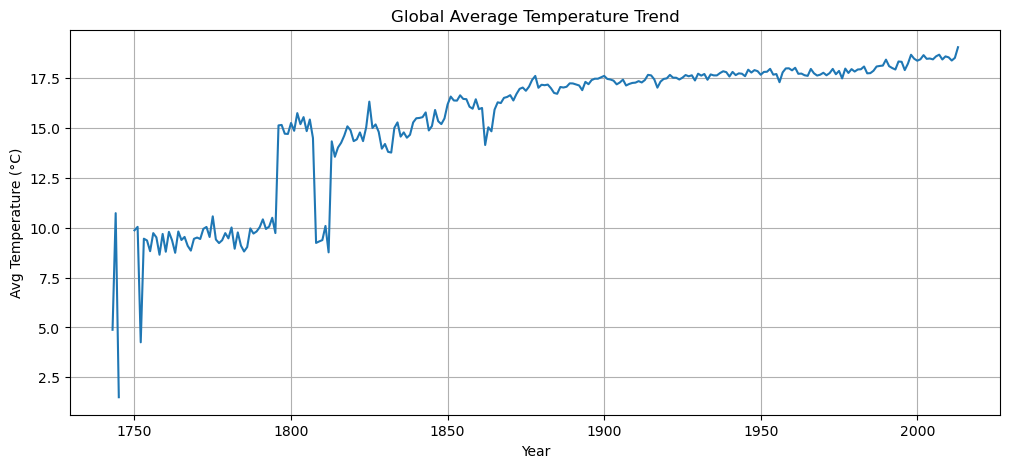

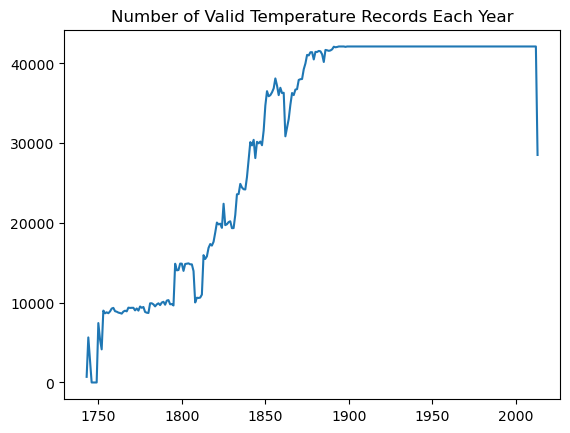

In [8]:
###温度趋势
global_temp=df.groupby("year")["AverageTemperature"].mean()
plt.figure(figsize=(12,5))
plt.plot(global_temp.index,global_temp.values)
plt.title("Global Average Temperature Trend")
plt.xlabel('Year')
plt.ylabel("Avg Temperature (°C)")
plt.grid(True)
plt.show()
years_counts = df.groupby("year")["AverageTemperature"].count()
plt.plot(years_counts.index, years_counts.values)
plt.title("Number of Valid Temperature Records Each Year")
plt.show()

In [9]:
valid_years=years_counts[years_counts>50].index
df_min50 = df[df["year"].isin(valid_years)]

global_temp = df_min50.groupby("year")["AverageTemperature"].mean()
rolling = global_temp.rolling(window=10, center=True).mean()
threshold = 3
mask = (global_temp - rolling).abs() < threshold
clean_temp = global_temp[mask]

df_clear = df_min50[df_min50["year"].isin(clean_temp.index)]

df_clear.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,year
110,1753-01-01,-1.259,8.151,Århus,Denmark,57.05N,10.33E,1753
111,1753-02-01,-0.285,3.715,Århus,Denmark,57.05N,10.33E,1753
112,1753-03-01,4.210,3.695,Århus,Denmark,57.05N,10.33E,1753
113,1753-04-01,6.765,6.727,Århus,Denmark,57.05N,10.33E,1753
114,1753-05-01,10.650,2.308,Århus,Denmark,57.05N,10.33E,1753


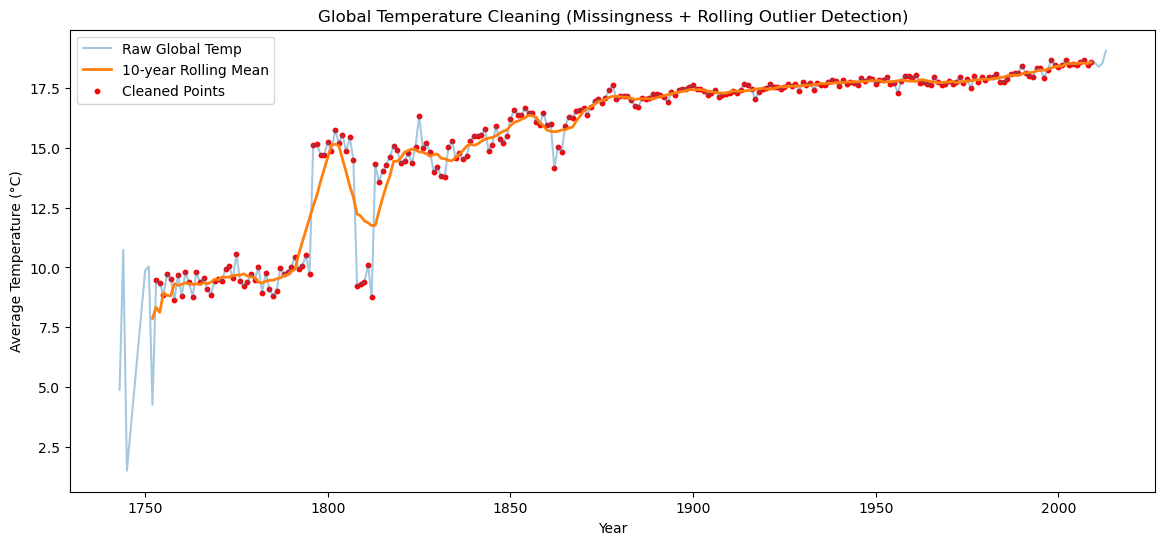

In [ ]:

plt.figure(figsize=(14,6))
plt.plot(global_temp.index, global_temp.values, label="Raw Global Temp", alpha=0.4)
plt.plot(rolling.index, rolling.values, label="10-year Rolling Mean", linewidth=2)
plt.scatter(clean_temp.index, clean_temp.values, label="Cleaned Points", color='red', s=10)
plt.legend()
plt.title("Global Temperature Cleaning (Missingness + Rolling Outlier Detection)")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.show()


- 出现了不符合事实的情况：1800年左右先升后降
    需要事实：真实全球温度变化不会在 20 年内突然升降 2°C 以上
    再去研究数据存在的真实原因：
    1. 看图发现新增了很多数据，可能在热带地区修了观测点
    2. >数据插补（imputation）算法导致的虚假趋势
    
    解决方向：
    1. 首先定位真实原因，发现国家不同了，见下
    2. 剔除1850年之前的数据

In [ ]:
##判断数据来源
for year in range(1790, 1821):  
    print(f"\n===== Year {year} =====")
    
    df_year = df[df["year"] == year]["Country"].value_counts()
    
    if df_year.empty:
        print("No data available.")
    else:
        print(df_year.head(5))




===== Year 1790 =====
Country
United States     1620
Russia            1440
Germany            972
United Kingdom     816
Spain              600
Name: count, dtype: int64

===== Year 1791 =====
Country
United States     1620
Russia            1440
Germany            972
United Kingdom     816
Spain              600
Name: count, dtype: int64

===== Year 1792 =====
Country
United States     1620
Russia            1440
Germany            972
United Kingdom     816
Spain              600
Name: count, dtype: int64

===== Year 1793 =====
Country
United States     1620
Russia            1440
Germany            972
United Kingdom     816
Spain              600
Name: count, dtype: int64

===== Year 1794 =====
Country
United States     1620
Russia            1440
Germany            972
United Kingdom     816
Spain              600
Name: count, dtype: int64

===== Year 1795 =====
Country
United States     1620
Russia            1440
Germany            972
United Kingdom     816
Spain            

1796年之后加入了很多印度4356，远超美俄1600，1400

但是之后十多年数据量几乎不变很显然并不合理，推测是插值算法的改变

---

不是观测导致的变化
而是“空间重建模型”本身在变化
>1796：插值模型高估印度 → 全球均值上升

>1805：插值模型下调估计 → 全球均值下降

从下图，可以看出1850年之后参与国家数恒定，因此我们线性规划剔除1850年之前的数据

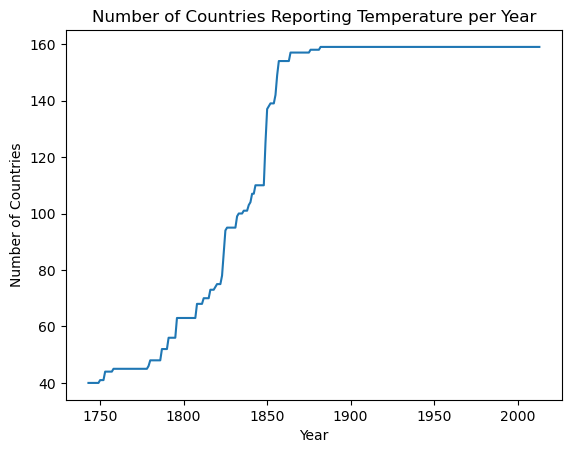

In [15]:
countries_per_year = df.groupby("year")["Country"].nunique()

plt.plot(countries_per_year)
plt.title("Number of Countries Reporting Temperature per Year")
plt.xlabel("Year")
plt.ylabel("Number of Countries")
plt.show()


In [21]:
###做线性回归
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
global_temp_1850 = df[df["year"] >= 1850].groupby("year")["AverageTemperature"].mean()

# 去除 NaN 年份
global_temp_1850 = global_temp_1850.dropna()

rolling = global_temp_1850.rolling(10, center=True).mean()
diff = (global_temp_1850 - rolling).abs()

# 自动剔除偏离超过 1.5°C 的点
clean_temp = global_temp_1850[diff < 1.5]

# 拆分 X, y
years = clean_temp.index.values.reshape(-1, 1)
temps = clean_temp.values 

model=LinearRegression()
model.fit(years,temps)
predicted=model.predict(years)
last_year = years.max()
future_years = np.arange(last_year+1, last_year+31).reshape(-1, 1)
future_pred = model.predict(future_years)

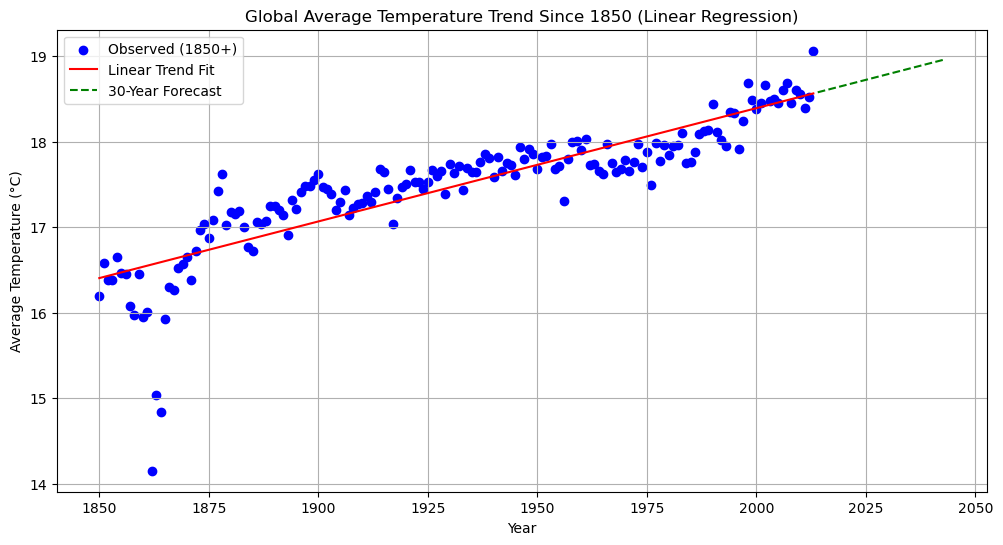

In [18]:
###模型评估
plt.figure(figsize=(12,6))

plt.scatter(years, temps, color='blue', label="Observed (1850+)")
plt.plot(years, predicted, color='red', label="Linear Trend Fit")
plt.plot(future_years, future_pred, color='green', linestyle='--', 
         label="30-Year Forecast")

plt.title("Global Average Temperature Trend Since 1850 (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
r2 = r2_score(temps, predicted)
rmse = np.sqrt(mean_squared_error(temps, predicted))

print("R-squared:", r2)
print("RMSE:", rmse)


R-squared: 0.7440921258196783
RMSE: 0.3674711086844038
